In [1]:
!pip install git+https://github.com/mhamilton723/FeatUp

  Cloning https://github.com/mhamilton723/FeatUp to /tmp/pip-req-build-kmci0we3
  Running command git clone --filter=blob:none --quiet https://github.com/mhamilton723/FeatUp /tmp/pip-req-build-kmci0we3
  Resolved https://github.com/mhamilton723/FeatUp to commit 6b5a6c0e91f75e69194807128dcbc39c3084a30d
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 94.3 MB/s eta 0:00:00
  Created wheel for featup: filename=featup-0.1.2-cp312-cp312-linux_x86_64.whl size=6335440 sha256=226009b0ea6d7c58887845205aec14d35bb8d7d651d504a54304d1a3f54778bf
  Stored in directory: /tmp/pip-ephem-wheel-cache-67j4s_km/wheels/dc/d6/4e/40155a4b984c03eb65f7

In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
Tesla T4


In [3]:
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

print("Drive ready")

Mounted at /content/drive
Drive ready


In [4]:
# Install FeatUp if not already installed
try:
    import featup
    print("FeatUp already installed")
except ImportError:
    print("Installing FeatUp...")
    !pip install git+https://github.com/mhamilton723/FeatUp -q
    print("Done")

FeatUp already installed


In [5]:
PROJECT_DIR  = "/content/drive/MyDrive/seal_tracking_colab"
DATA_DIR     = f"{PROJECT_DIR}/data"
FRAME_DIR    = f"{DATA_DIR}/frames"
OUTPUT_DIR   = f"{PROJECT_DIR}/outputs"
FIGURE_DIR   = f"{OUTPUT_DIR}/figures"
FEATUP_DIR   = f"{OUTPUT_DIR}/featup"

from pathlib import Path
Path(FIGURE_DIR).mkdir(parents=True, exist_ok=True)
Path(FEATUP_DIR).mkdir(parents=True, exist_ok=True)

print("Paths ready")

Paths ready


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from pathlib import Path
from sklearn.decomposition import PCA
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [7]:
# Load standard DINOv2 — for native and 728 upscaling approaches
dino_model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dino_model = dino_model.to(device).eval()
print("DINOv2 loaded")

# Load FeatUp upsampler for DINOv2
featup_model = torch.hub.load(
    "mhamilton723/FeatUp",
    "dinov2",
    use_norm=False
)
featup_model = featup_model.to(device).eval()
print("FeatUp upsampler loaded")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 393MB/s]


DINOv2 loaded
The repository mhamilton723_FeatUp does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/mhamilton723/FeatUp/zipball/main" to /root/.cache/torch/hub/main.zip


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Downloading: "https://marhamilresearch4.blob.core.windows.net/feature-upsampling-public/pretrained/no_norm/dinov2_jbu_stack_cocostuff.ckpt" to /root/.cache/torch/hub/checkpoints/dinov2_jbu_stack_cocostuff.ckpt


100%|██████████| 2.04M/2.04M [00:00<00:00, 6.66MB/s]

FeatUp upsampler loaded


In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_transform(image_size):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

transform_518 = make_transform(518)
transform_728 = make_transform(728)
transform_448 = make_transform(448)

print("Transforms ready")
print("Native DINOv2   → 518×518 input → 37×37 feature grid")
print("Input upscaling → 728×728 input → 52×52 feature grid")
print("FeatUp          → 448×448 input → 32×32 token grid → 512×512 output (4×2 decoder)")

Transforms ready
Native DINOv2   → 518×518 input → 37×37 feature grid
Input upscaling → 728×728 input → 52×52 feature grid
FeatUp          → 448×448 input → 32×32 token grid → 512×512 output (4×2 decoder)


In [10]:
def extract_dino_features(image_path, model, transform, device):

    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model.forward_features(tensor)
        patch_tokens = out["x_norm_patchtokens"]   # (1, num_patches, 384)

    patch_tokens = patch_tokens[0].cpu().numpy()
    grid_size    = int(patch_tokens.shape[0] ** 0.5)
    features     = patch_tokens.reshape(grid_size, grid_size, 384)
    return image, features


In [12]:
def extract_featup_features(image_path, model, transform, device):

    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        hr_features = model(tensor)   # (1, 384, 512, 512)

    hr_features = hr_features[0].permute(1, 2, 0).cpu().numpy()
    return image, hr_features


In [13]:
def features_to_pca_rgb(features, n_components=3):

    H, W, C = features.shape
    flat    = features.reshape(-1, C)
    pca     = PCA(n_components=n_components, random_state=42)
    reduced = pca.fit_transform(flat)

    for i in range(n_components):
        col_min = reduced[:, i].min()
        col_max = reduced[:, i].max()
        if col_max > col_min:
            reduced[:, i] = (reduced[:, i] - col_min) / (col_max - col_min)

    return reduced.reshape(H, W, n_components)


In [14]:
def upsample_to(feature_map, target_h, target_w):

    return cv2.resize(
        feature_map.astype(np.float32),
        (target_w, target_h),
        interpolation=cv2.INTER_LINEAR
    )

print("PCA visualization functions defined")

PCA visualization functions defined


### Resolution Comparison: Native vs Input Upscaling vs FeatUp

In [15]:
frame_dir_v1    = Path(FRAME_DIR) / "video_01_dense"
frame_paths     = sorted(frame_dir_v1.glob("*.jpg"))
reference_frame = frame_paths[0]

print(f"Reference frame: {reference_frame.name}")
print(f"Total frames available: {len(frame_paths)}")

Reference frame: frame_0000.jpg
Total frames available: 106


In [16]:
print("Extracting features...")

print("1. Native DINOv2 (518×518 input)...")
image, features_native = extract_dino_features(
    reference_frame, dino_model, transform_518, device
)
print(f"    Feature shape: {features_native.shape}")

print("2. Input upscaling (728×728 input)...")
_, features_728 = extract_dino_features(
    reference_frame, dino_model, transform_728, device
)
print(f"    Feature shape: {features_728.shape}")

print("3. FeatUp (448×448 input → 512×512 features via 4×2 decoder stages)...")
_, features_featup = extract_featup_features(
    reference_frame, featup_model, transform_448, device
)
print(f"    Feature shape: {features_featup.shape}")

print("\nAll features extracted.")

Extracting features...
1. Native DINOv2 (518×518 input)...
    Feature shape: (37, 37, 384)
2. Input upscaling (728×728 input)...
    Feature shape: (52, 52, 384)
3. FeatUp (448×448 input → 512×512 features via 4×2 decoder stages)...
    Feature shape: (512, 512, 384)

All features extracted.


In [17]:
print("Computing PCA visualizations...")

pca_native = features_to_pca_rgb(features_native)
pca_728    = features_to_pca_rgb(features_728)
pca_featup = features_to_pca_rgb(features_featup)

# Upsample native and 728 to 512×512 for display only
pca_native_display = upsample_to(pca_native, 512, 512)
pca_728_display    = upsample_to(pca_728,    512, 512)
pca_featup_display = pca_featup   # already 512×512

print("PCA done")

Computing PCA visualizations...
PCA done


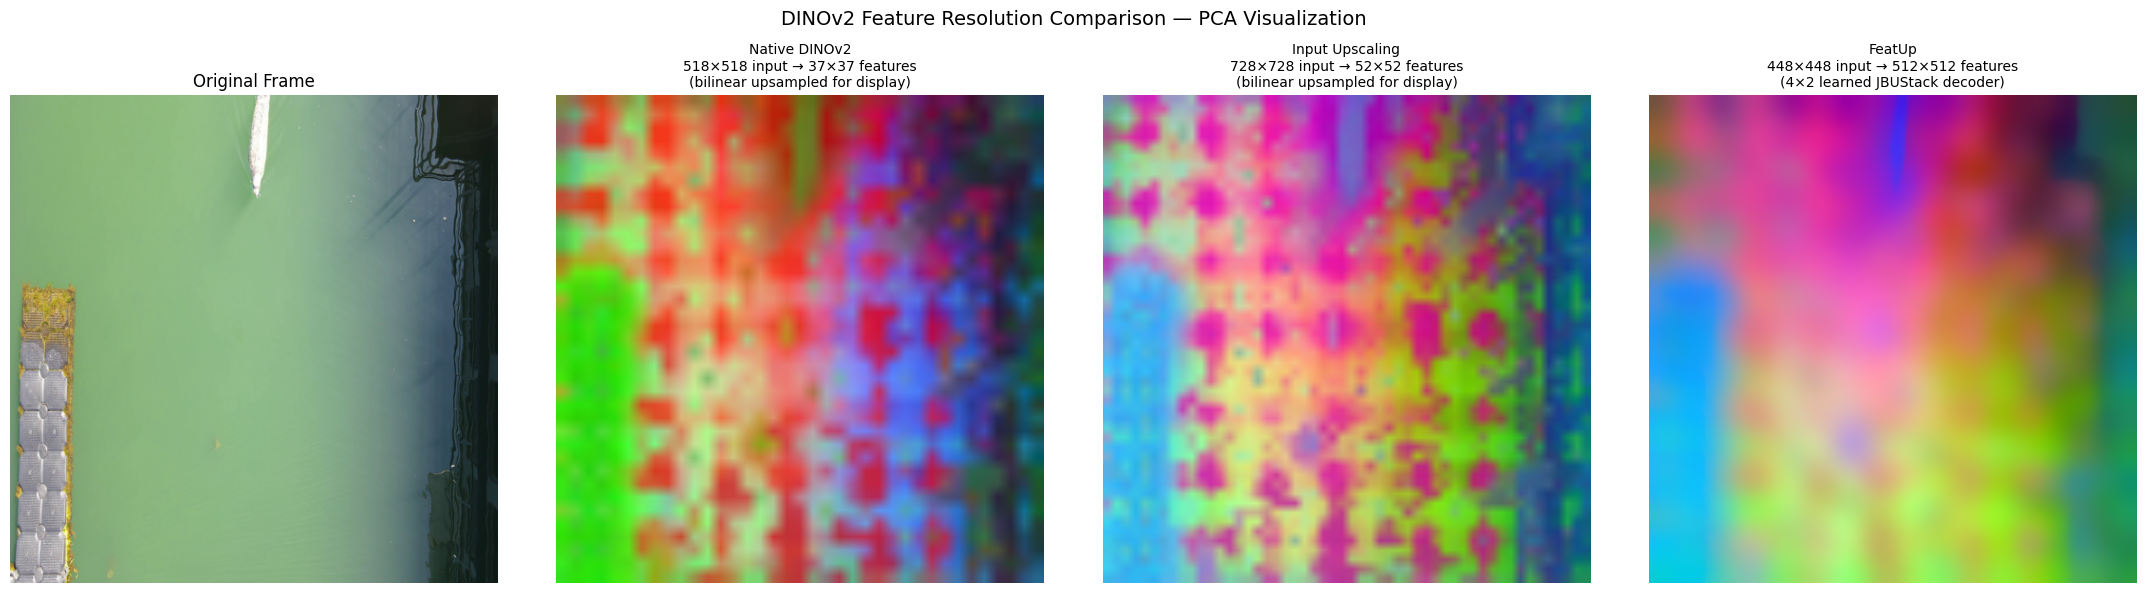

Saved: resolution_comparison_pca.png


In [18]:
image_display = image.resize((512, 512))

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(image_display)
axes[0].set_title("Original Frame", fontsize=12)
axes[0].axis("off")

axes[1].imshow(pca_native_display)
axes[1].set_title(
    "Native DINOv2\n518×518 input → 37×37 features\n(bilinear upsampled for display)",
    fontsize=10
)
axes[1].axis("off")

axes[2].imshow(pca_728_display)
axes[2].set_title(
    "Input Upscaling\n728×728 input → 52×52 features\n(bilinear upsampled for display)",
    fontsize=10
)
axes[2].axis("off")

axes[3].imshow(pca_featup_display)
axes[3].set_title(
    "FeatUp\n448×448 input → 512×512 features\n(4×2 learned JBUStack decoder)",
    fontsize=10
)
axes[3].axis("off")

plt.suptitle("DINOv2 Feature Resolution Comparison — PCA Visualization", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"{FEATUP_DIR}/resolution_comparison_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: resolution_comparison_pca.png")

* All three methods highlight both the seal and a prominent background object, confirming that PCA responds to visual distinctiveness rather than semantic seal identity.
* The key difference is boundary sharpness: native DINOv2 shows blocky patch-level boundaries, input upscaling improves this moderately, and FeatUp produces the sharpest seal outline with the most spatially precise feature separation.

### Similarity Map Comparison


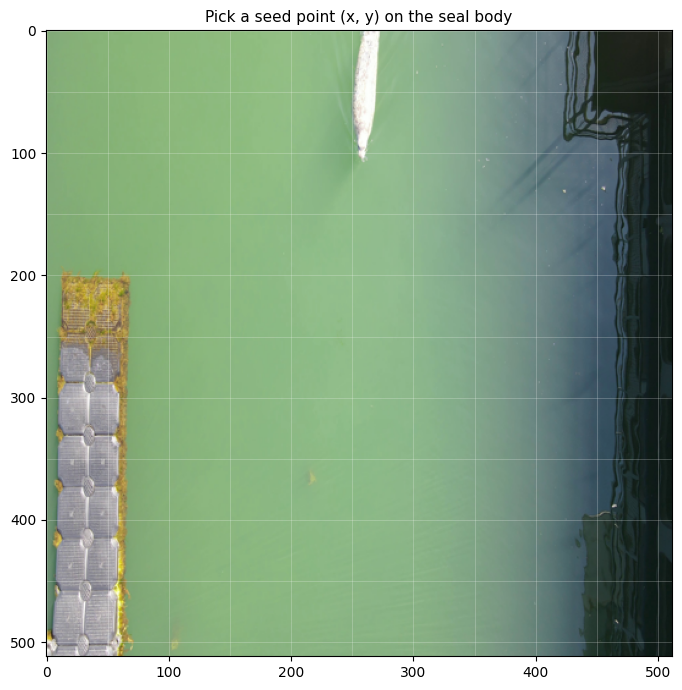

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(image.resize((512, 512)))
for x in range(0, 512, 50):
    ax.axvline(x, color='white', alpha=0.3, linewidth=0.5)
for y in range(0, 512, 50):
    ax.axhline(y, color='white', alpha=0.3, linewidth=0.5)
ax.set_title("Pick a seed point (x, y) on the seal body", fontsize=11)
plt.tight_layout()
plt.show()

In [20]:
SEED_X = 260
SEED_Y = 50

print(f"Seed point set to: ({SEED_X}, {SEED_Y}) in 512×512 space")

Seed point set to: (260, 50) in 512×512 space


In [21]:
def compute_similarity_map(features, seed_x, seed_y, input_size):

    H, W, C = features.shape
    fy = np.clip(int(seed_y / input_size * H), 0, H - 1)
    fx = np.clip(int(seed_x / input_size * W), 0, W - 1)

    ref      = features[fy, fx]
    ref      = ref / (np.linalg.norm(ref) + 1e-8)
    flat     = features.reshape(-1, C)
    norms    = np.linalg.norm(flat, axis=1, keepdims=True) + 1e-8
    sim      = (flat / norms) @ ref
    return sim.reshape(H, W)

In [22]:
# Compute similarity maps
sim_native = compute_similarity_map(features_native, SEED_X, SEED_Y, input_size=512)
sim_728    = compute_similarity_map(features_728,    SEED_X, SEED_Y, input_size=512)
sim_featup = compute_similarity_map(features_featup, SEED_X, SEED_Y, input_size=512)

sim_native_display = cv2.resize(sim_native.astype(np.float32), (512, 512), interpolation=cv2.INTER_LINEAR)
sim_728_display    = cv2.resize(sim_728.astype(np.float32),    (512, 512), interpolation=cv2.INTER_LINEAR)

print(f"Native similarity map:  {sim_native.shape}")
print(f"728 similarity map:     {sim_728.shape}")
print(f"FeatUp similarity map:  {sim_featup.shape}")

Native similarity map:  (37, 37)
728 similarity map:     (52, 52)
FeatUp similarity map:  (512, 512)


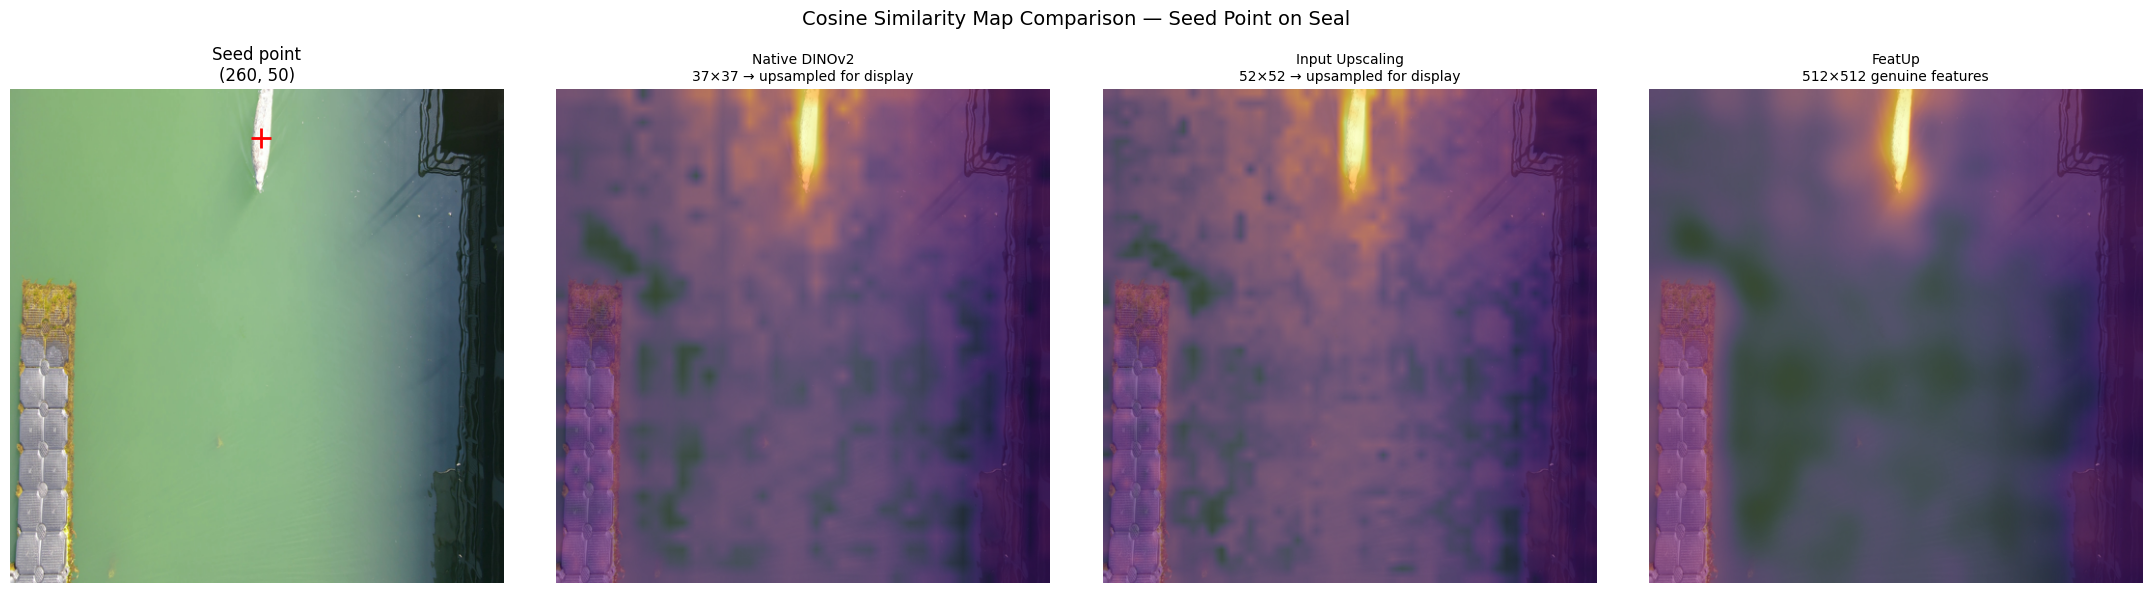

Saved: similarity_map_comparison.png


In [23]:
img_arr = np.array(image.resize((512, 512)))

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(img_arr)
axes[0].plot(SEED_X, SEED_Y, 'r+', markersize=15, markeredgewidth=2)
axes[0].set_title(f"Seed point\n({SEED_X}, {SEED_Y})", fontsize=12)
axes[0].axis("off")

axes[1].imshow(img_arr)
axes[1].imshow(sim_native_display, cmap="inferno", alpha=0.6)
axes[1].set_title("Native DINOv2\n37×37 → upsampled for display", fontsize=10)
axes[1].axis("off")

axes[2].imshow(img_arr)
axes[2].imshow(sim_728_display, cmap="inferno", alpha=0.6)
axes[2].set_title("Input Upscaling\n52×52 → upsampled for display", fontsize=10)
axes[2].axis("off")

axes[3].imshow(img_arr)
axes[3].imshow(sim_featup, cmap="inferno", alpha=0.6)
axes[3].set_title("FeatUp\n512×512 genuine features", fontsize=10)
axes[3].axis("off")

plt.suptitle("Cosine Similarity Map Comparison — Seed Point on Seal", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"{FEATUP_DIR}/similarity_map_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: similarity_map_comparison.png")

* Native DINOv2 produces a blocky heatmap. High similarity is confined to coarse patch regions with visible grid structure.
* Both native and 728 show a "candle glow" effect. similarity bleeds slightly into surrounding water pixels due to bilinear upsampling of the coarse feature grid; this is an interpolation artifact, not real signal.
* Boundary patches in native and 728 show partial similarity (visible as a green tint at the seal edge) because a 14×14 patch overlapping the boundary contains both seal and water pixels, its feature is a blend of both.
* FeatUp eliminates the glow effect entirely, similarity drops sharply at the seal boundary with no bleed into surrounding water. It produces clean seal separation, only the seal body is highlighted, everything else is distinctly low similarity.

### Boundary Sharpness Analysis

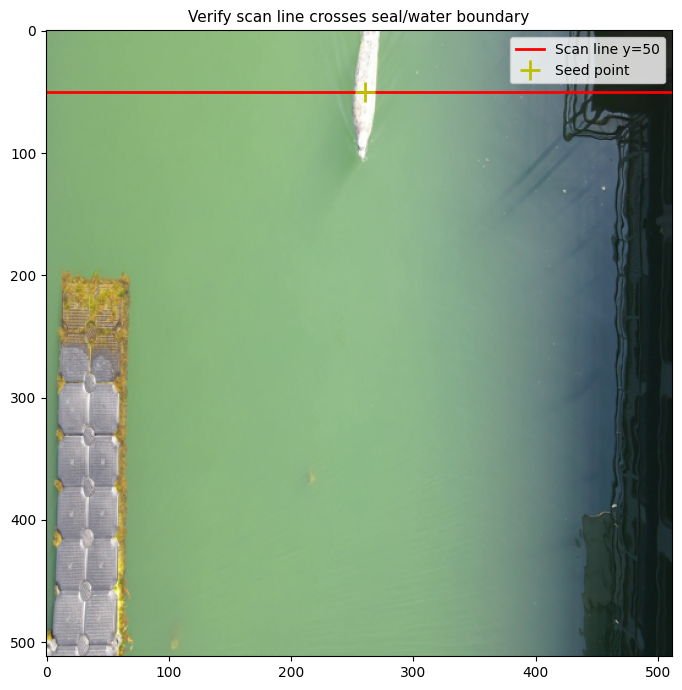

In [24]:
BOUNDARY_Y = 50

# Verify the scan line placement
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.imshow(image.resize((512, 512)))
ax.axhline(BOUNDARY_Y, color='red', linewidth=2, label=f'Scan line y={BOUNDARY_Y}')
ax.plot(SEED_X, SEED_Y, 'y+', markersize=15, markeredgewidth=2, label='Seed point')
ax.legend(fontsize=10)
ax.set_title("Verify scan line crosses seal/water boundary", fontsize=11)
plt.tight_layout()
plt.show()

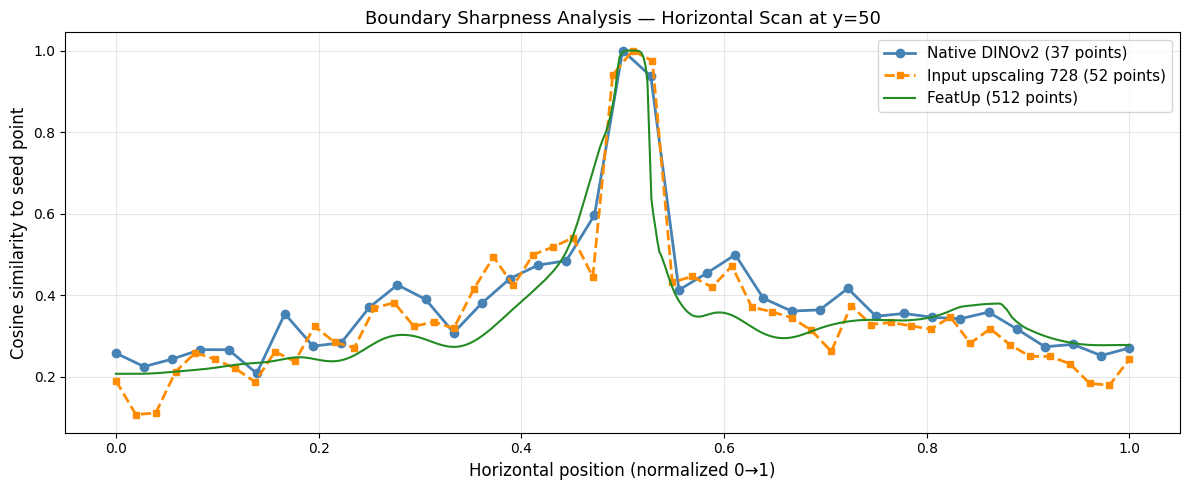

Saved: boundary_sharpness_analysis.png


In [26]:
# Map BOUNDARY_Y to each feature grid's y-coordinate
y_native = int(BOUNDARY_Y / 512 * sim_native.shape[0])
y_728    = int(BOUNDARY_Y / 512 * sim_728.shape[0])
y_featup = int(BOUNDARY_Y / 512 * sim_featup.shape[0])

line_native = sim_native[y_native, :]
line_728    = sim_728[y_728, :]
line_featup = sim_featup[y_featup, :]

# Normalize x-axis to [0,1] so all lines can be compared fairly
x_native = np.linspace(0, 1, len(line_native))
x_728    = np.linspace(0, 1, len(line_728))
x_featup = np.linspace(0, 1, len(line_featup))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_native, line_native, 'o-',  color='steelblue',  linewidth=2,
        markersize=6, label=f'Native DINOv2 ({len(line_native)} points)')
ax.plot(x_728,    line_728,    's--', color='darkorange',  linewidth=2,
        markersize=5, label=f'Input upscaling 728 ({len(line_728)} points)')
ax.plot(x_featup, line_featup, '-',   color='forestgreen', linewidth=1.5,
        label=f'FeatUp ({len(line_featup)} points)')

ax.set_xlabel("Horizontal position (normalized 0→1)", fontsize=12)
ax.set_ylabel("Cosine similarity to seed point", fontsize=12)
ax.set_title(f"Boundary Sharpness Analysis — Horizontal Scan at y={BOUNDARY_Y}", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FEATUP_DIR}/boundary_sharpness_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: boundary_sharpness_analysis.png")

* Native DINOv2 shows a clear staircase pattern, similarity values change in discrete steps corresponding to patch boundaries.
* Input upscaling (728) produces finer steps but the staircase pattern is still visible.
* FeatUp produces a smooth curve with a steep drop precisely at the seal/water boundary. This confirms FeatUp features carry genuine sub-patch spatial information rather than interpolated patch values.

### Multi-Frame Featup Consistency

In [29]:
sample_frames = frame_paths[::10][:10]
print(f"Processing {len(sample_frames)} frames...")

fig, axes = plt.subplots(len(sample_frames), 3, figsize=(15, 5 * len(sample_frames)))

for i, frame_path in enumerate(sample_frames):
    image_i, feat_native_i = extract_dino_features(
        frame_path, dino_model, transform_518, device
    )
    _, feat_featup_i = extract_featup_features(
        frame_path, featup_model, transform_448, device
    )

    pca_nat_i = upsample_to(features_to_pca_rgb(feat_native_i), 512, 512)
    pca_fup_i = features_to_pca_rgb(feat_featup_i)   # already 512×512
    img_i     = np.array(image_i.resize((512, 512)))

    axes[i][0].imshow(img_i)
    axes[i][0].set_title(frame_path.name, fontsize=8)
    axes[i][0].axis("off")

    axes[i][1].imshow(pca_nat_i)
    axes[i][1].set_title("Native DINOv2 PCA", fontsize=9)
    axes[i][1].axis("off")

    axes[i][2].imshow(pca_fup_i)
    axes[i][2].set_title("FeatUp PCA", fontsize=9)
    axes[i][2].axis("off")

    print(f"  Frame {i+1}/{len(sample_frames)} done")

plt.suptitle("Multi-Frame: Native DINOv2 vs FeatUp PCA — Video 1", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f"{FEATUP_DIR}/multiframe_native_vs_featup.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: multiframe_native_vs_featup.png")

Output hidden; open in https://colab.research.google.com to view.

* FeatUp consistently produces sharp, spatially precise features across all 10 frames including frames where the seal is partially submerged or exiting the frame.
* In frames 5 and 7 the PCA color assignment is inverted compared to other frames (the seal appears pink rather than dark blue) but the spatial separation and boundary sharpness remain intact. This color inconsistency is a known limitation of per-frame PCA, which has no fixed color assignment across frames. It is not a failure of FeatUp's feature quality.


**Conclusion**:
FeatUp justifies its added complexity over simple input upscaling. Across all three evaluations, PCA visualization, similarity mapping, and boundary sharpness analysis, FeatUp consistently produces superior results. The boundary sharpness ploy is the most convincing eveidence.

